In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde



Processing threshold = 700 ...


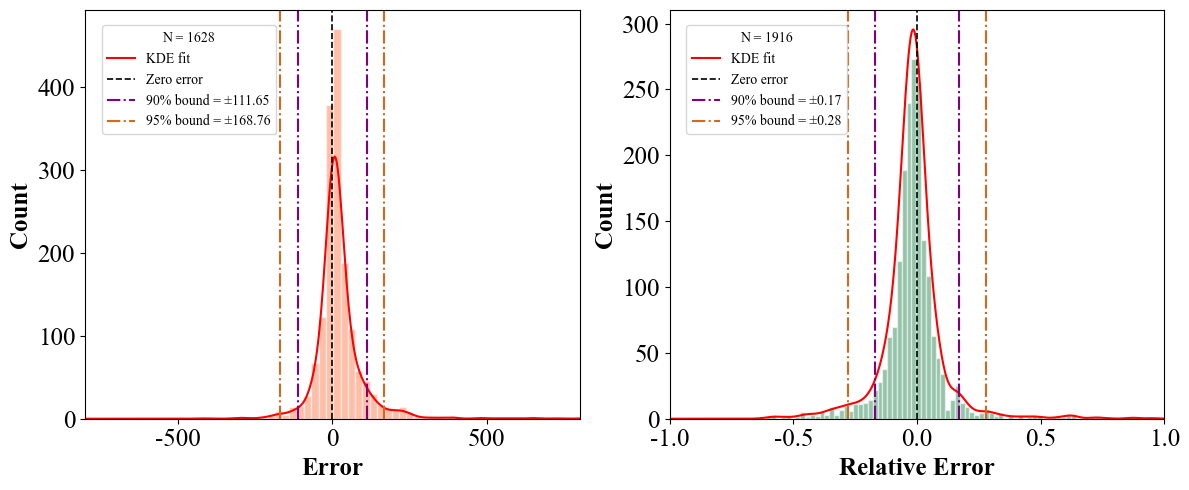

  Saved: /Users/wangxujie/Desktop/GNN-Multi-v2-tenfold-ChemBERT2-copy/data/error_distribution_threshold_700.png
  Low RI  (1628):  90% = ±111.65, 95% = ±168.76
  High RI (1916): 90% = ±0.1716, 95% = ±0.2770

Summary saved to /Users/wangxujie/Desktop/GNN-Multi-v2-tenfold-ChemBERT2-copy/data/error_distribution_thresholds_summary.csv
 Threshold  N_low  N_high  N_equal  Low_90%_bound  Low_95%_bound  High_90%_bound  High_95%_bound
       700   1628    1916        7     111.648706     168.759581        0.171556        0.277044


In [2]:

plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['axes.unicode_minus'] = False


# ====== 路径设置 ======
base_dir = '/Users/wangxujie/Desktop/GNN-Multi-v2-tenfold-ChemBERT2-copy'
output_dir = os.path.join(base_dir, 'data')
os.makedirs(output_dir, exist_ok=True)


# ====== 读取十折测试集预测结果 ======
csv_path = os.path.join(output_dir, 'all_folds_errors.csv')
combined = pd.read_csv(csv_path)
combined['Correct'] = combined['Correct'].astype(float)
combined['Predict'] = combined['Predict'].astype(float)
combined['Error'] = combined['Predict'] - combined['Correct']
combined['AbsError'] = combined['Error'].abs()
combined['SignedRelError'] = combined['Error'] / combined['Correct']


# ====== 绘图函数 ======
def plot_signed_error_distribution(ax, values, xlabel, color, xlim):
    """绘制带正负的误差/相对误差直方图，叠加 KDE 拟合线与对称阈值线。"""
    values = np.asarray(values)
    q90 = np.percentile(np.abs(values), 90)
    q95 = np.percentile(np.abs(values), 95)

    ax.set_xlim(-xlim, xlim)
    ax.hist(values, bins=80, color=color, edgecolor='white', alpha=0.5, density=False)

    # KDE 拟合线
    kde = gaussian_kde(values)
    x_grid = np.linspace(-xlim, xlim, 500)
    # 将KDE曲线缩放到Count尺度，使其与频数直方图对应
    counts, bin_edges = np.histogram(values, bins=80, range=(-xlim, xlim))
    kde_values = kde(x_grid)
    scale_factor = counts.sum() * (bin_edges[1] - bin_edges[0])
    ax.plot(x_grid, kde_values * scale_factor, color='red', linewidth=1.5, label='KDE fit')

    ax.axvline(x=0, color='black', linestyle='--', linewidth=1.2, label='Zero error')
    ax.axvline(x=q90, color='purple', linestyle='-.', linewidth=1.5,
               label=f'90% bound = ±{q90:.2f}')
    ax.axvline(x=-q90, color='purple', linestyle='-.', linewidth=1.5)
    ax.axvline(x=q95, color='chocolate', linestyle='-.', linewidth=1.5,
               label=f'95% bound = ±{q95:.2f}')
    ax.axvline(x=-q95, color='chocolate', linestyle='-.', linewidth=1.5)
    ax.set_xlabel(xlabel, fontsize=18, fontweight='bold')
    ax.set_ylabel('Count', fontsize=18, fontweight='bold')
    ax.tick_params(axis='both', labelsize=18)
    ax.legend(title=f'N = {len(values)}', fontsize=10, title_fontsize=10,
              loc='upper left', bbox_to_anchor=(0.02, 0.98))


# ====== 待扫描的 RI 分界点 ======
thresholds = [700]
summary_records = []

for threshold in thresholds:
    print(f'\nProcessing threshold = {threshold} ...')

    df_low = combined[combined['Correct'] < threshold].copy()
    df_high = combined[combined['Correct'] > threshold].copy()
    df_equal = combined[combined['Correct'] == threshold]

    n_low = len(df_low)
    n_high = len(df_high)
    n_equal = len(df_equal)

    # 计算覆盖阈值
    q90_low = np.percentile(np.abs(df_low['Error']), 90)
    q95_low = np.percentile(np.abs(df_low['Error']), 95)
    q90_high = np.percentile(np.abs(df_high['SignedRelError']), 90)
    q95_high = np.percentile(np.abs(df_high['SignedRelError']), 95)

    summary_records.append({
        'Threshold': threshold,
        'N_low': n_low,
        'N_high': n_high,
        'N_equal': n_equal,
        'Low_90%_bound': q90_low,
        'Low_95%_bound': q95_low,
        'High_90%_bound': q90_high,
        'High_95%_bound': q95_high,
    })

    # 绘图
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    plot_signed_error_distribution(
        axes[0], df_low['Error'],
        xlabel='Error',
        color='coral',
        xlim=800
    )

    plot_signed_error_distribution(
        axes[1], df_high['SignedRelError'],
        xlabel='Relative Error',
        color='seagreen',
        xlim=1.0
    )

    plt.tight_layout()
    plot_path = os.path.join(output_dir, f'error_distribution_threshold_{threshold}.png')
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f'  Saved: {plot_path}')
    print(f'  Low RI  ({n_low}):  90% = ±{q90_low:.2f}, 95% = ±{q95_low:.2f}')
    print(f'  High RI ({n_high}): 90% = ±{q90_high:.4f}, 95% = ±{q95_high:.4f}')


# ====== 保存汇总结果 ======
summary_df = pd.DataFrame(summary_records)
summary_path = os.path.join(output_dir, 'error_distribution_thresholds_summary.csv')
summary_df.to_csv(summary_path, index=False)
print(f'\nSummary saved to {summary_path}')
print(summary_df.to_string(index=False))
